In [ ]:
##Install dependencies

!pip install -q "pillow<11"
!pip install -q ultralytics

In [ ]:
##Imports + config
import os
import glob
import yaml
import torch
from IPython.display import Image, display, clear_output

CONFIG = {
    "img_size": 416,
    "batch_size": 16,
    "epochs": 100,
    "conf_threshold": 0.4,
    "run_name": "yolov8_results",
    "base_model": "yolov8n.pt",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Setup complete. Using torch {torch.__version__} on {device}")

In [ ]:
##Mount Drive + unzip dataset
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = "/content/BCCD-1"
DRIVE_ZIP_PATH = "/content/drive/MyDrive/ML_Datasets /BCCD.v1i.yolov8.zip"

!mkdir -p {DATASET_DIR}
!unzip -q "{DRIVE_ZIP_PATH}" -d {DATASET_DIR}

DATA_YAML = os.path.join(DATASET_DIR, "data.yaml")
with open(DATA_YAML, "r") as f:
    print(f.read())

In [ ]:
## Read number of classes
with open(DATA_YAML, "r") as stream:
    data_yaml = yaml.safe_load(stream)

num_classes = data_yaml["nc"]
class_names = data_yaml.get("names", [])
print(f"Detected {num_classes} classes: {class_names}")


In [101]:
## Load pretrained YOLOv8 model
from ultralytics import YOLO

model = YOLO("weights/best.pt")

In [ ]:
##Train
%%time
model.train(
    data=DATA_YAML,
    imgsz=CONFIG["img_size"],
    batch=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    name=CONFIG["run_name"],
    exist_ok=True,
)

RUN_DIR = model.trainer.save_dir
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
BEST_WEIGHTS = os.path.join(WEIGHTS_DIR, "best.pt")

confusion_matrix_normalized.png


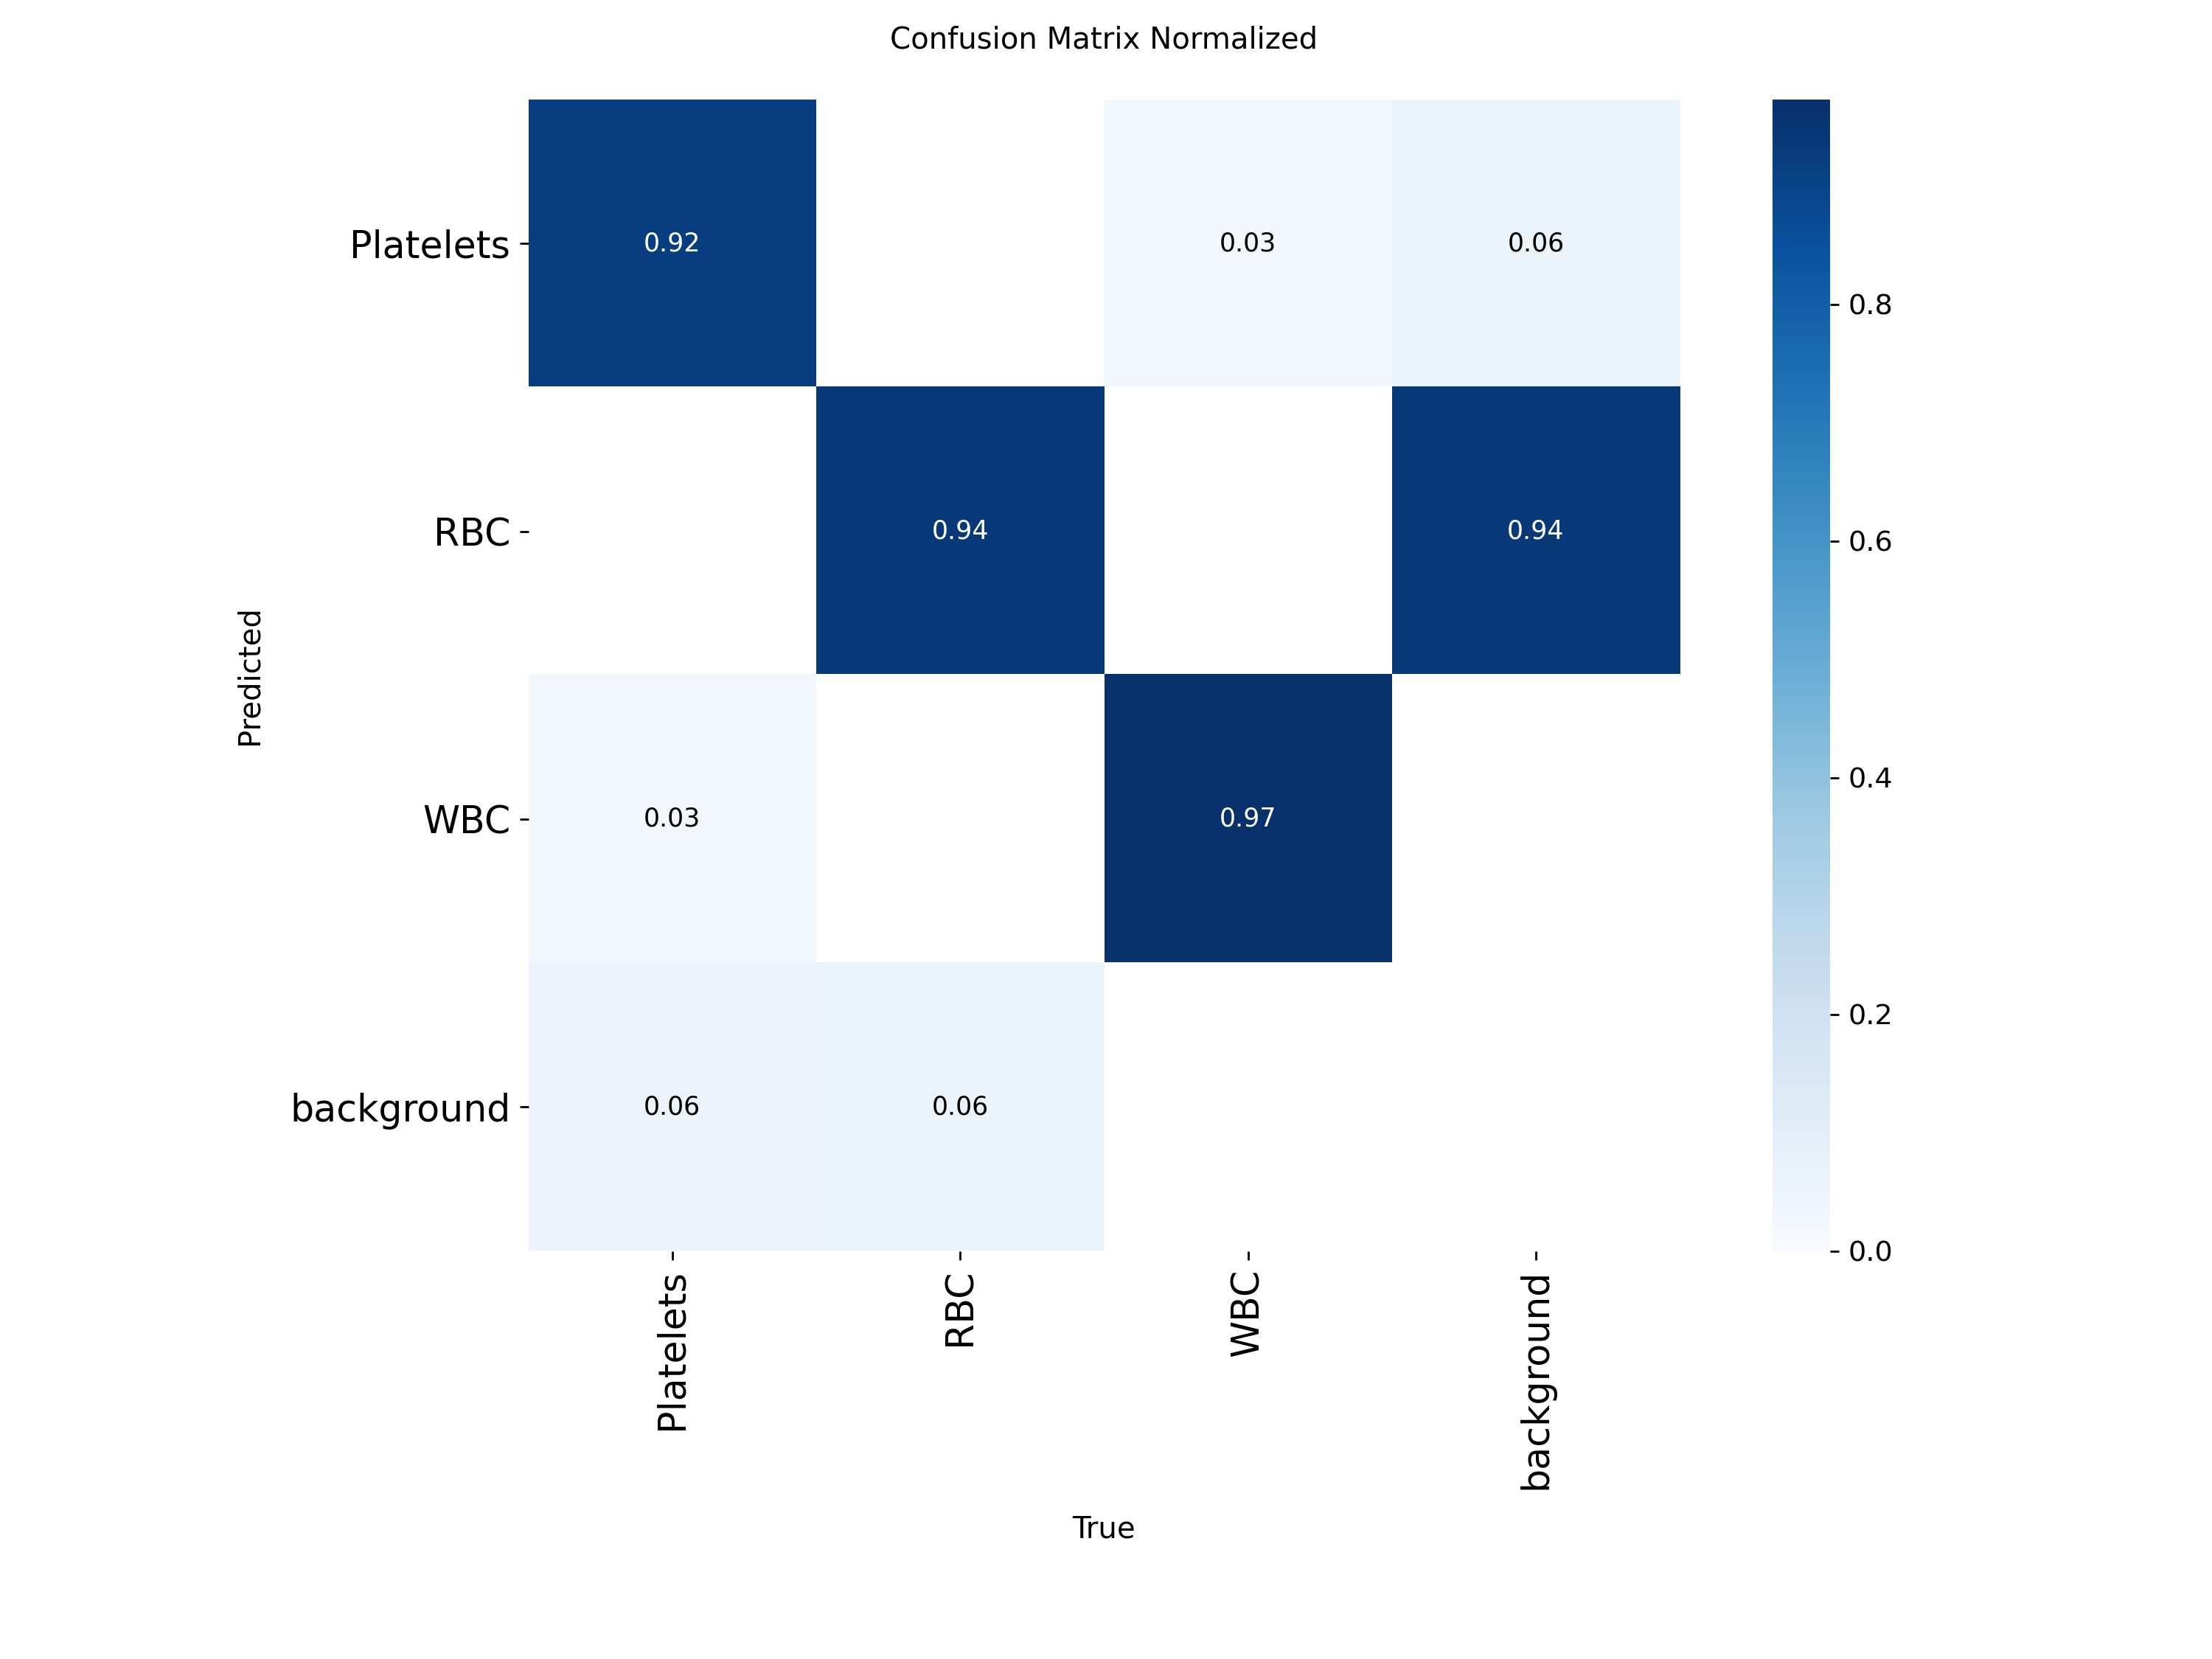

confusion_matrix.png


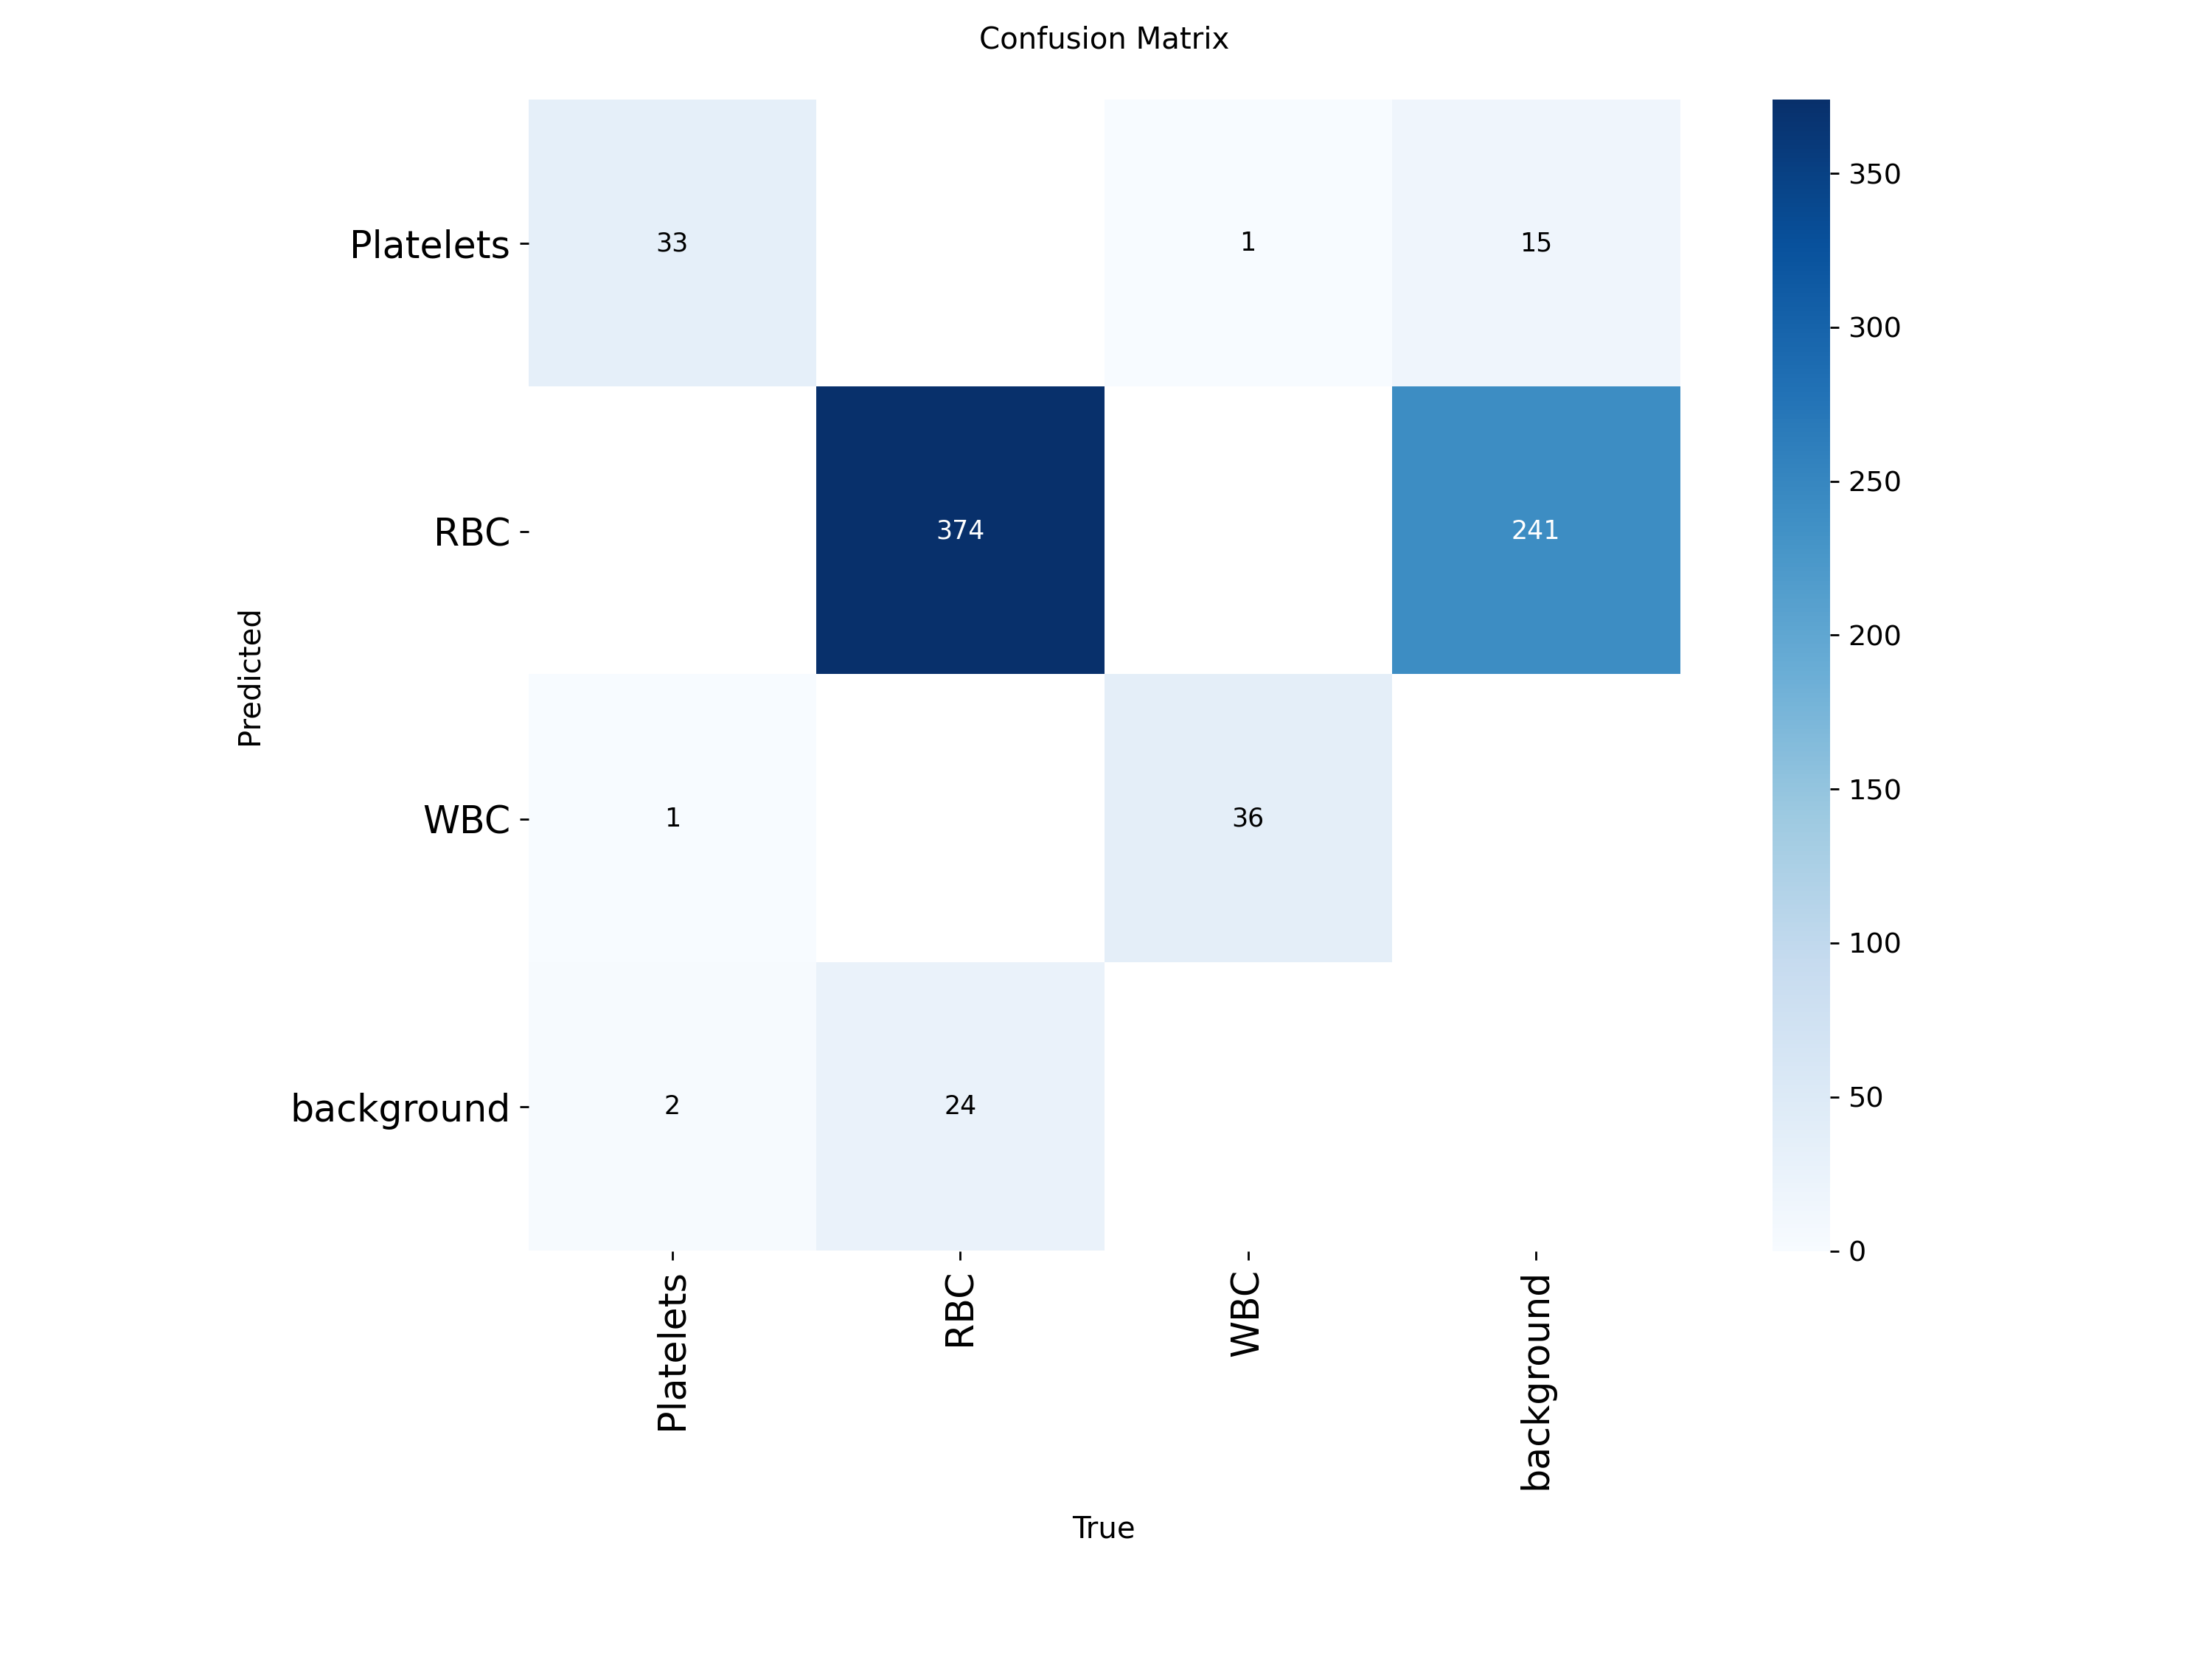

BoxPR_curve.png


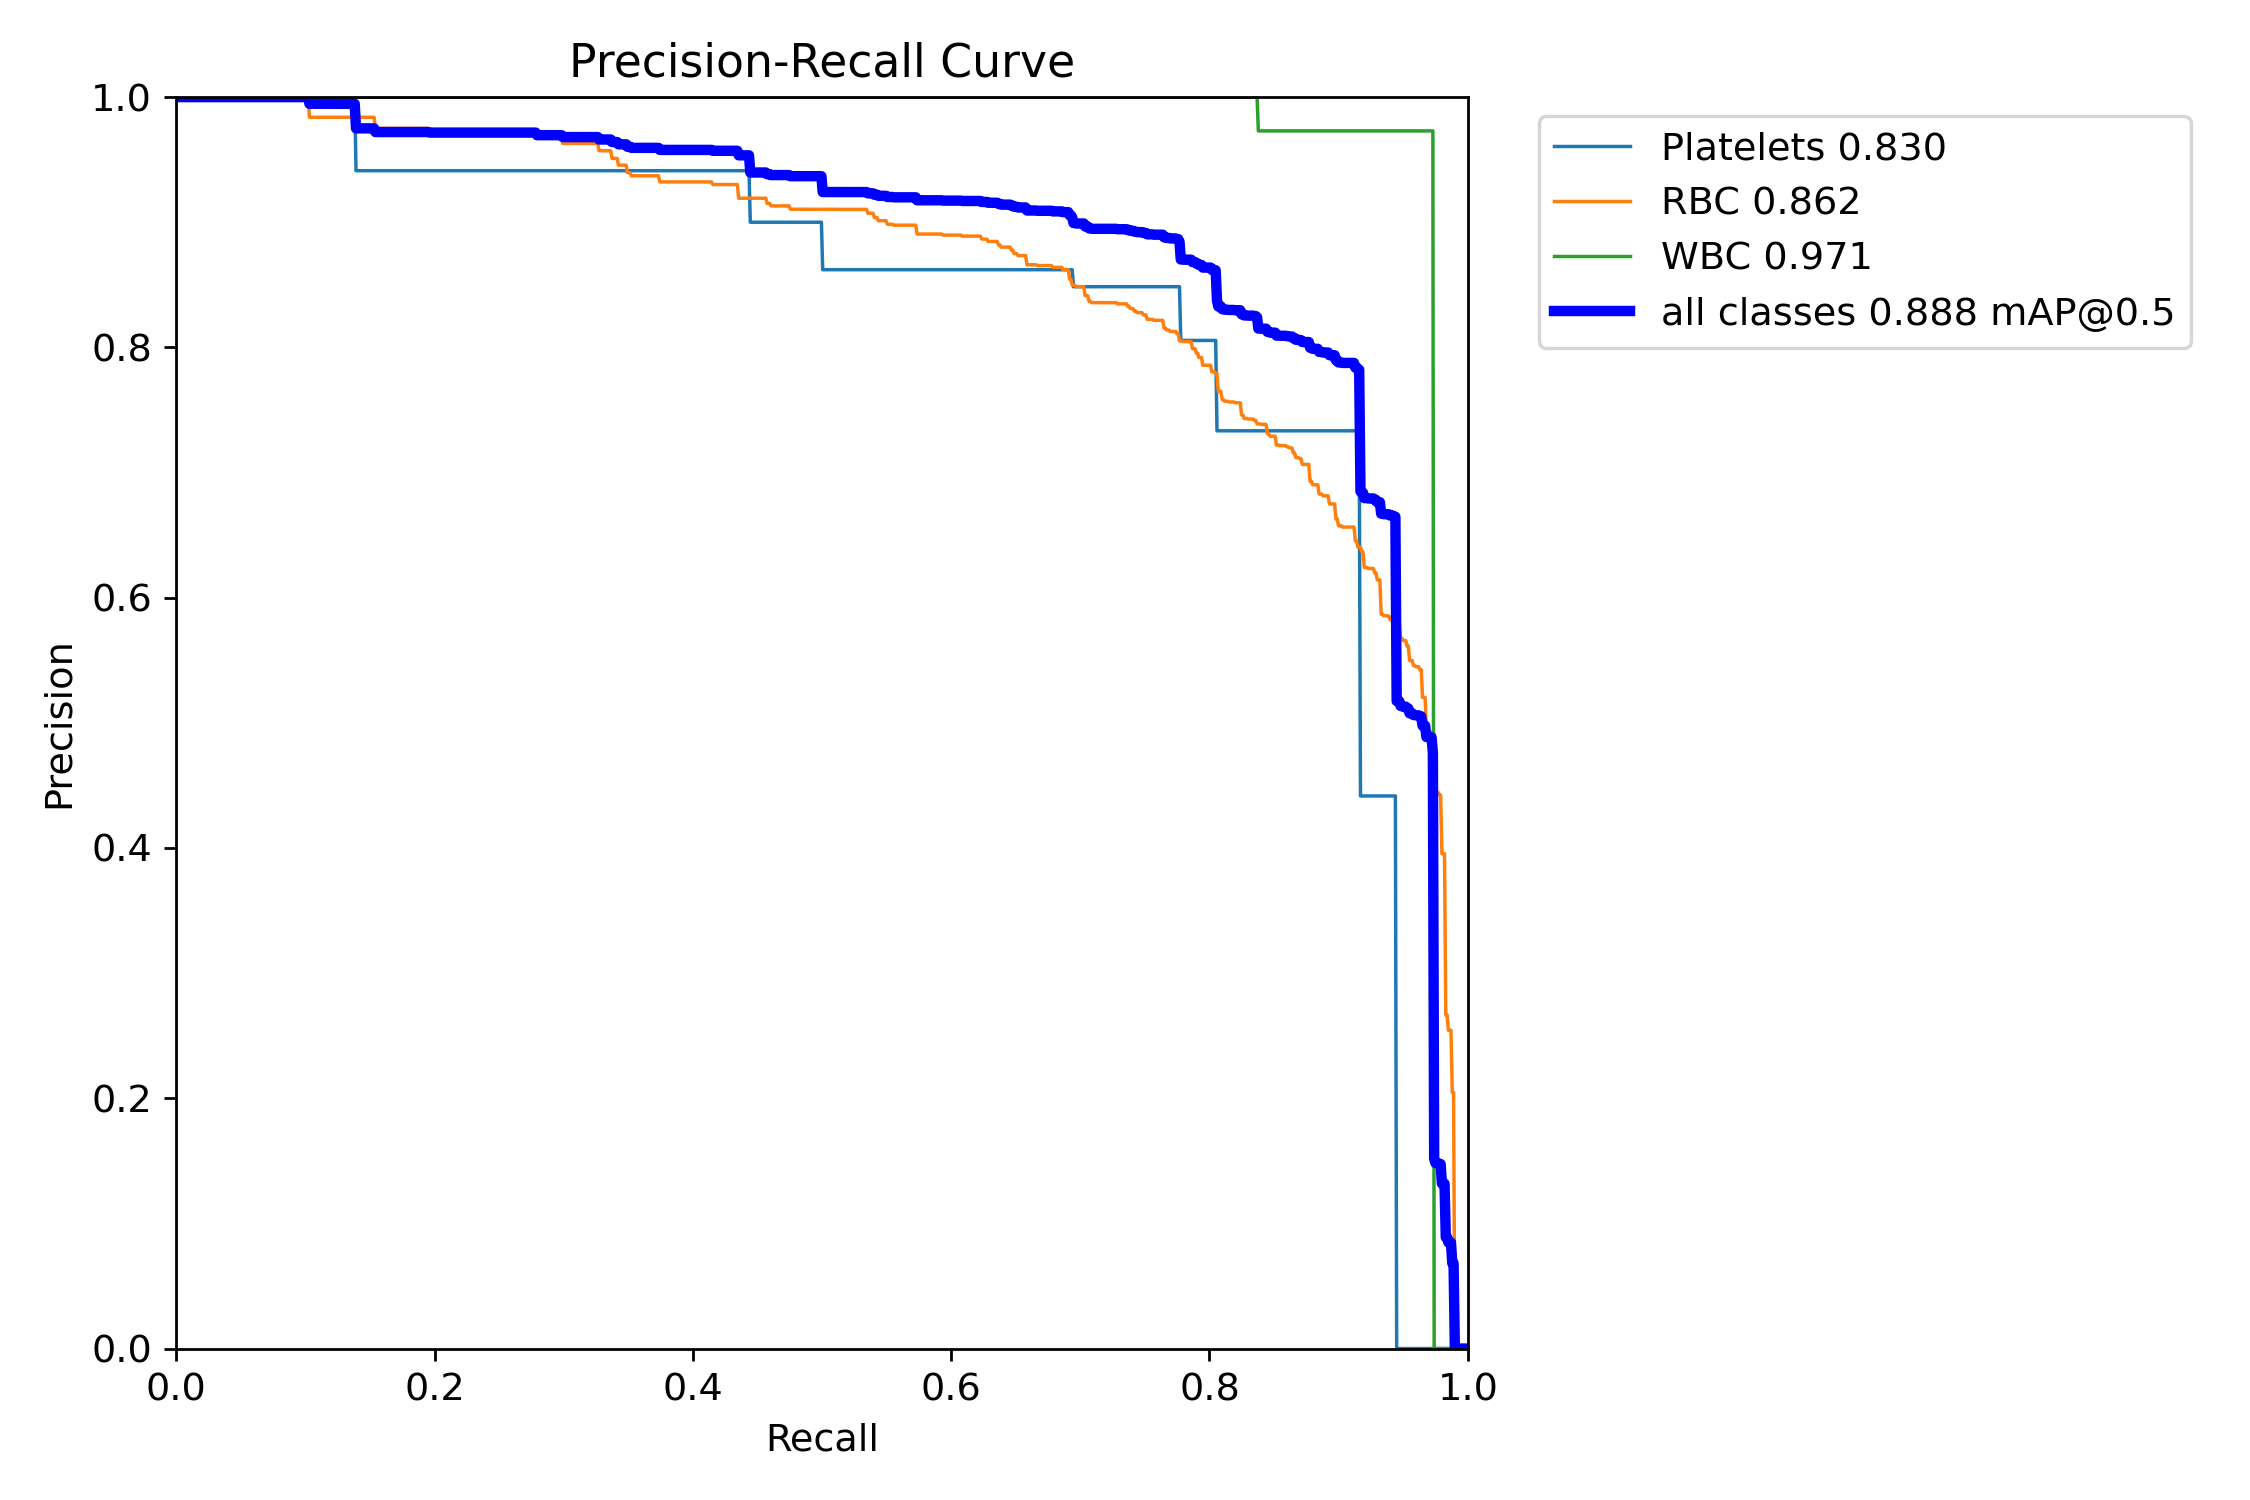

BoxP_curve.png


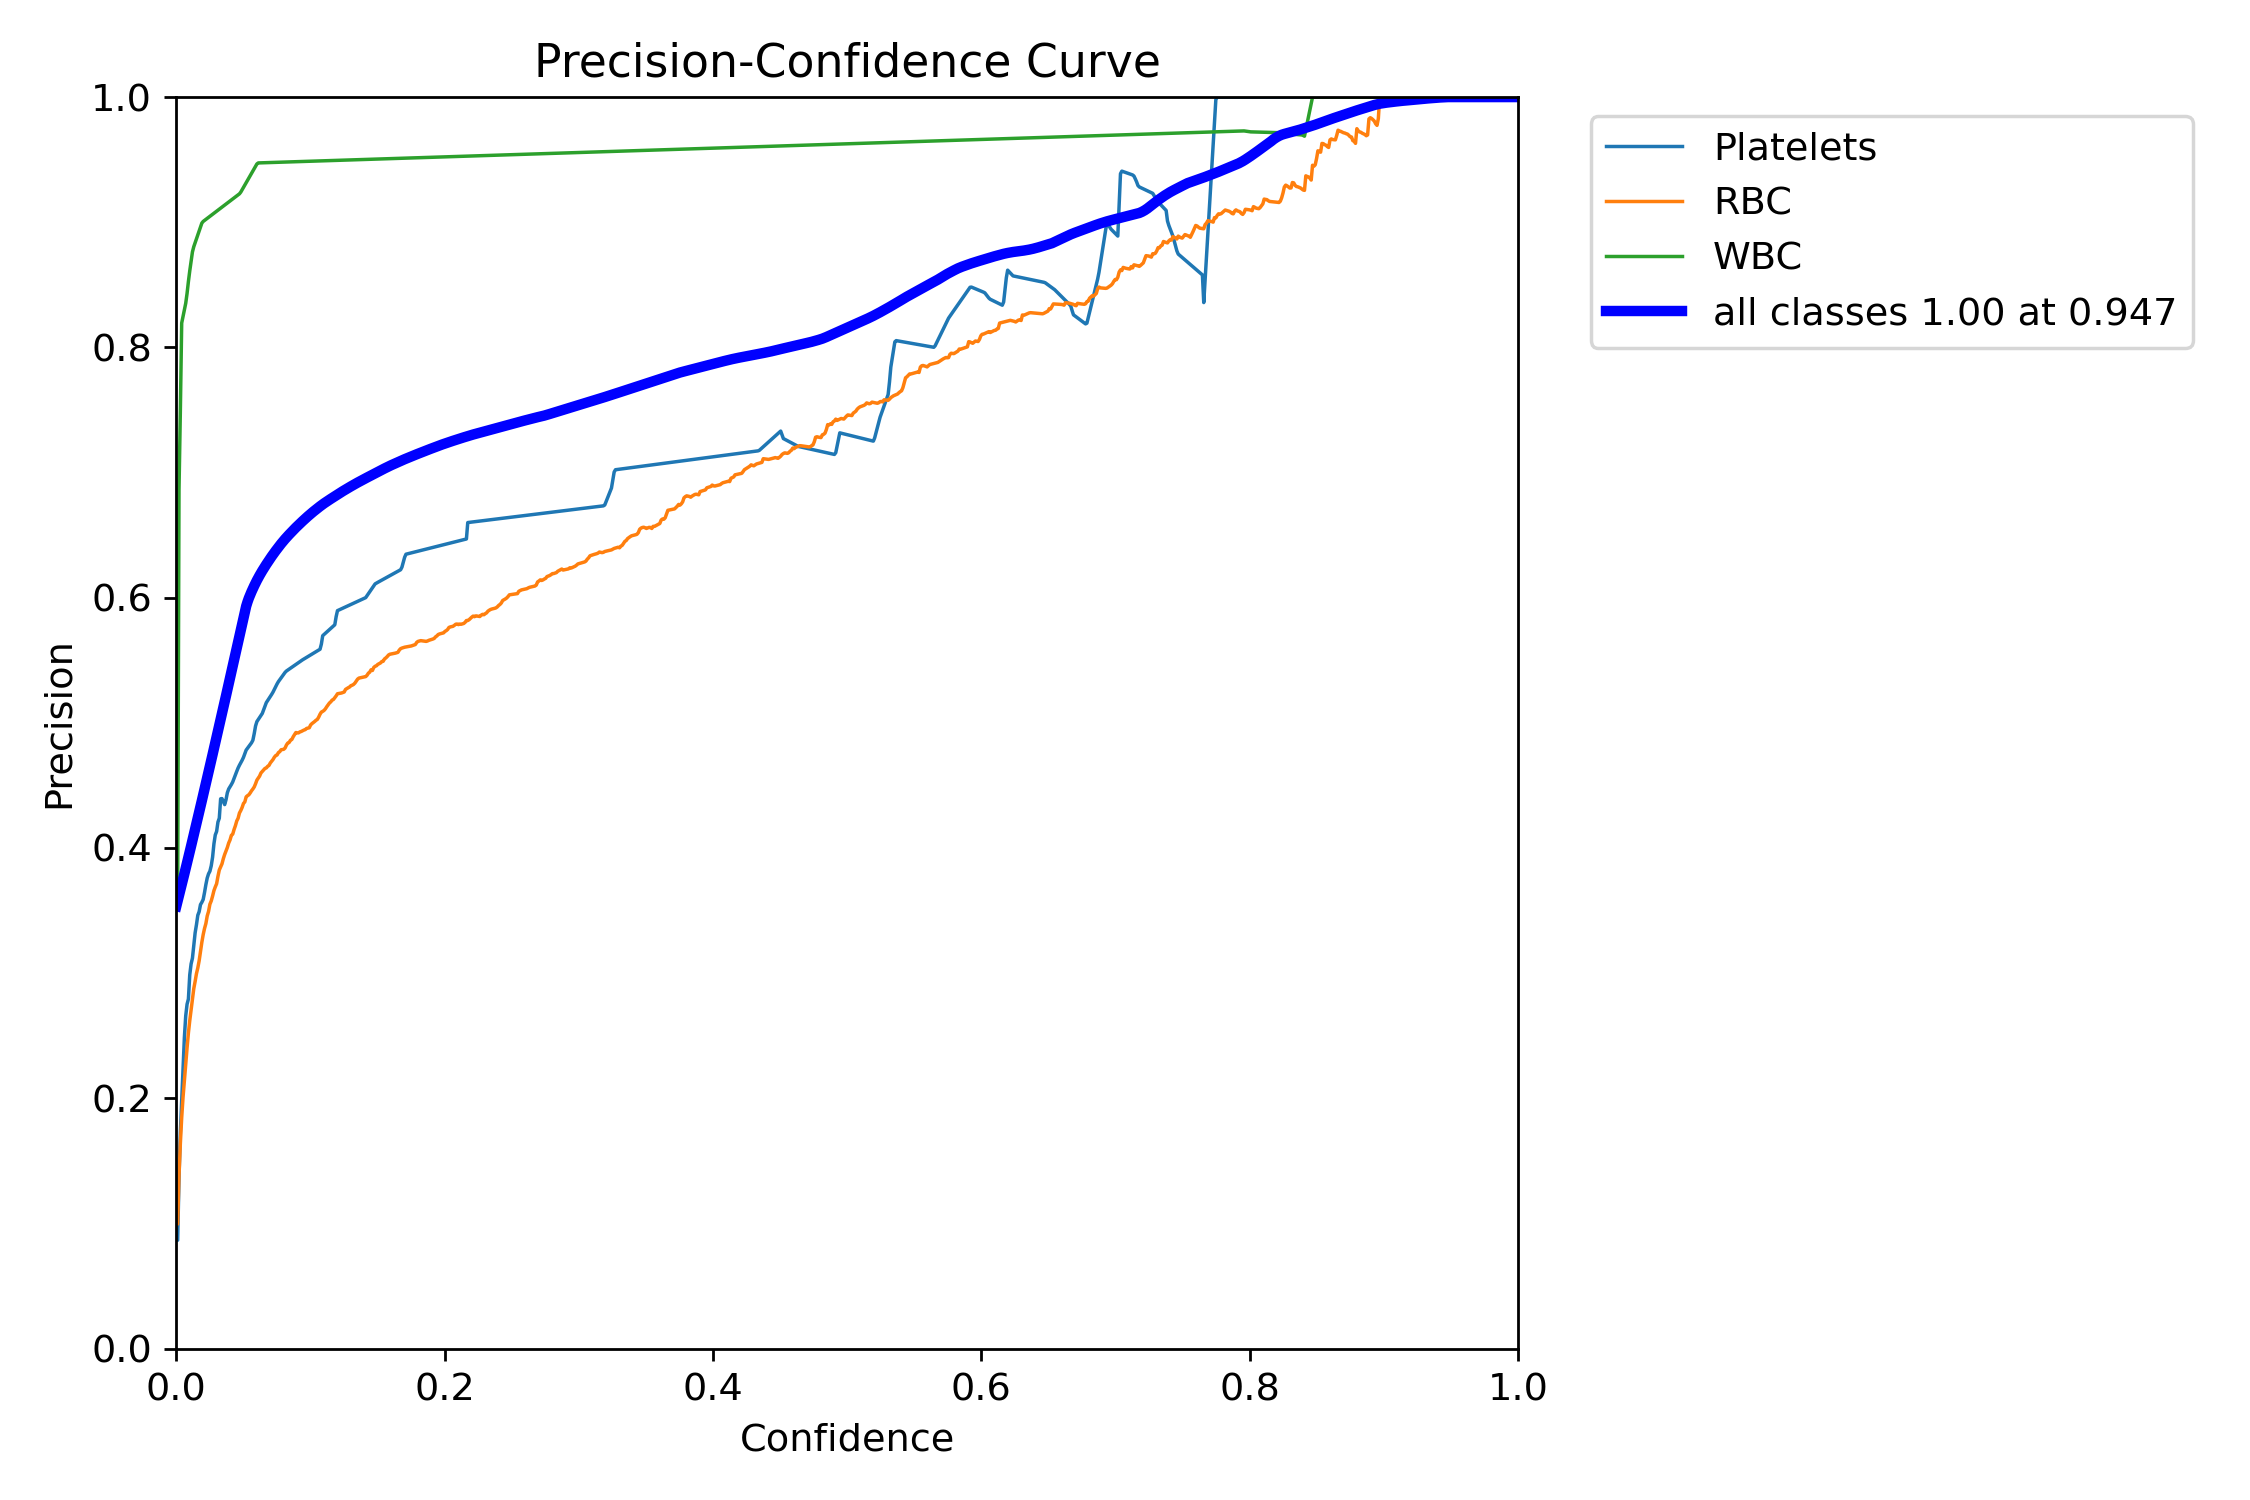

BoxR_curve.png


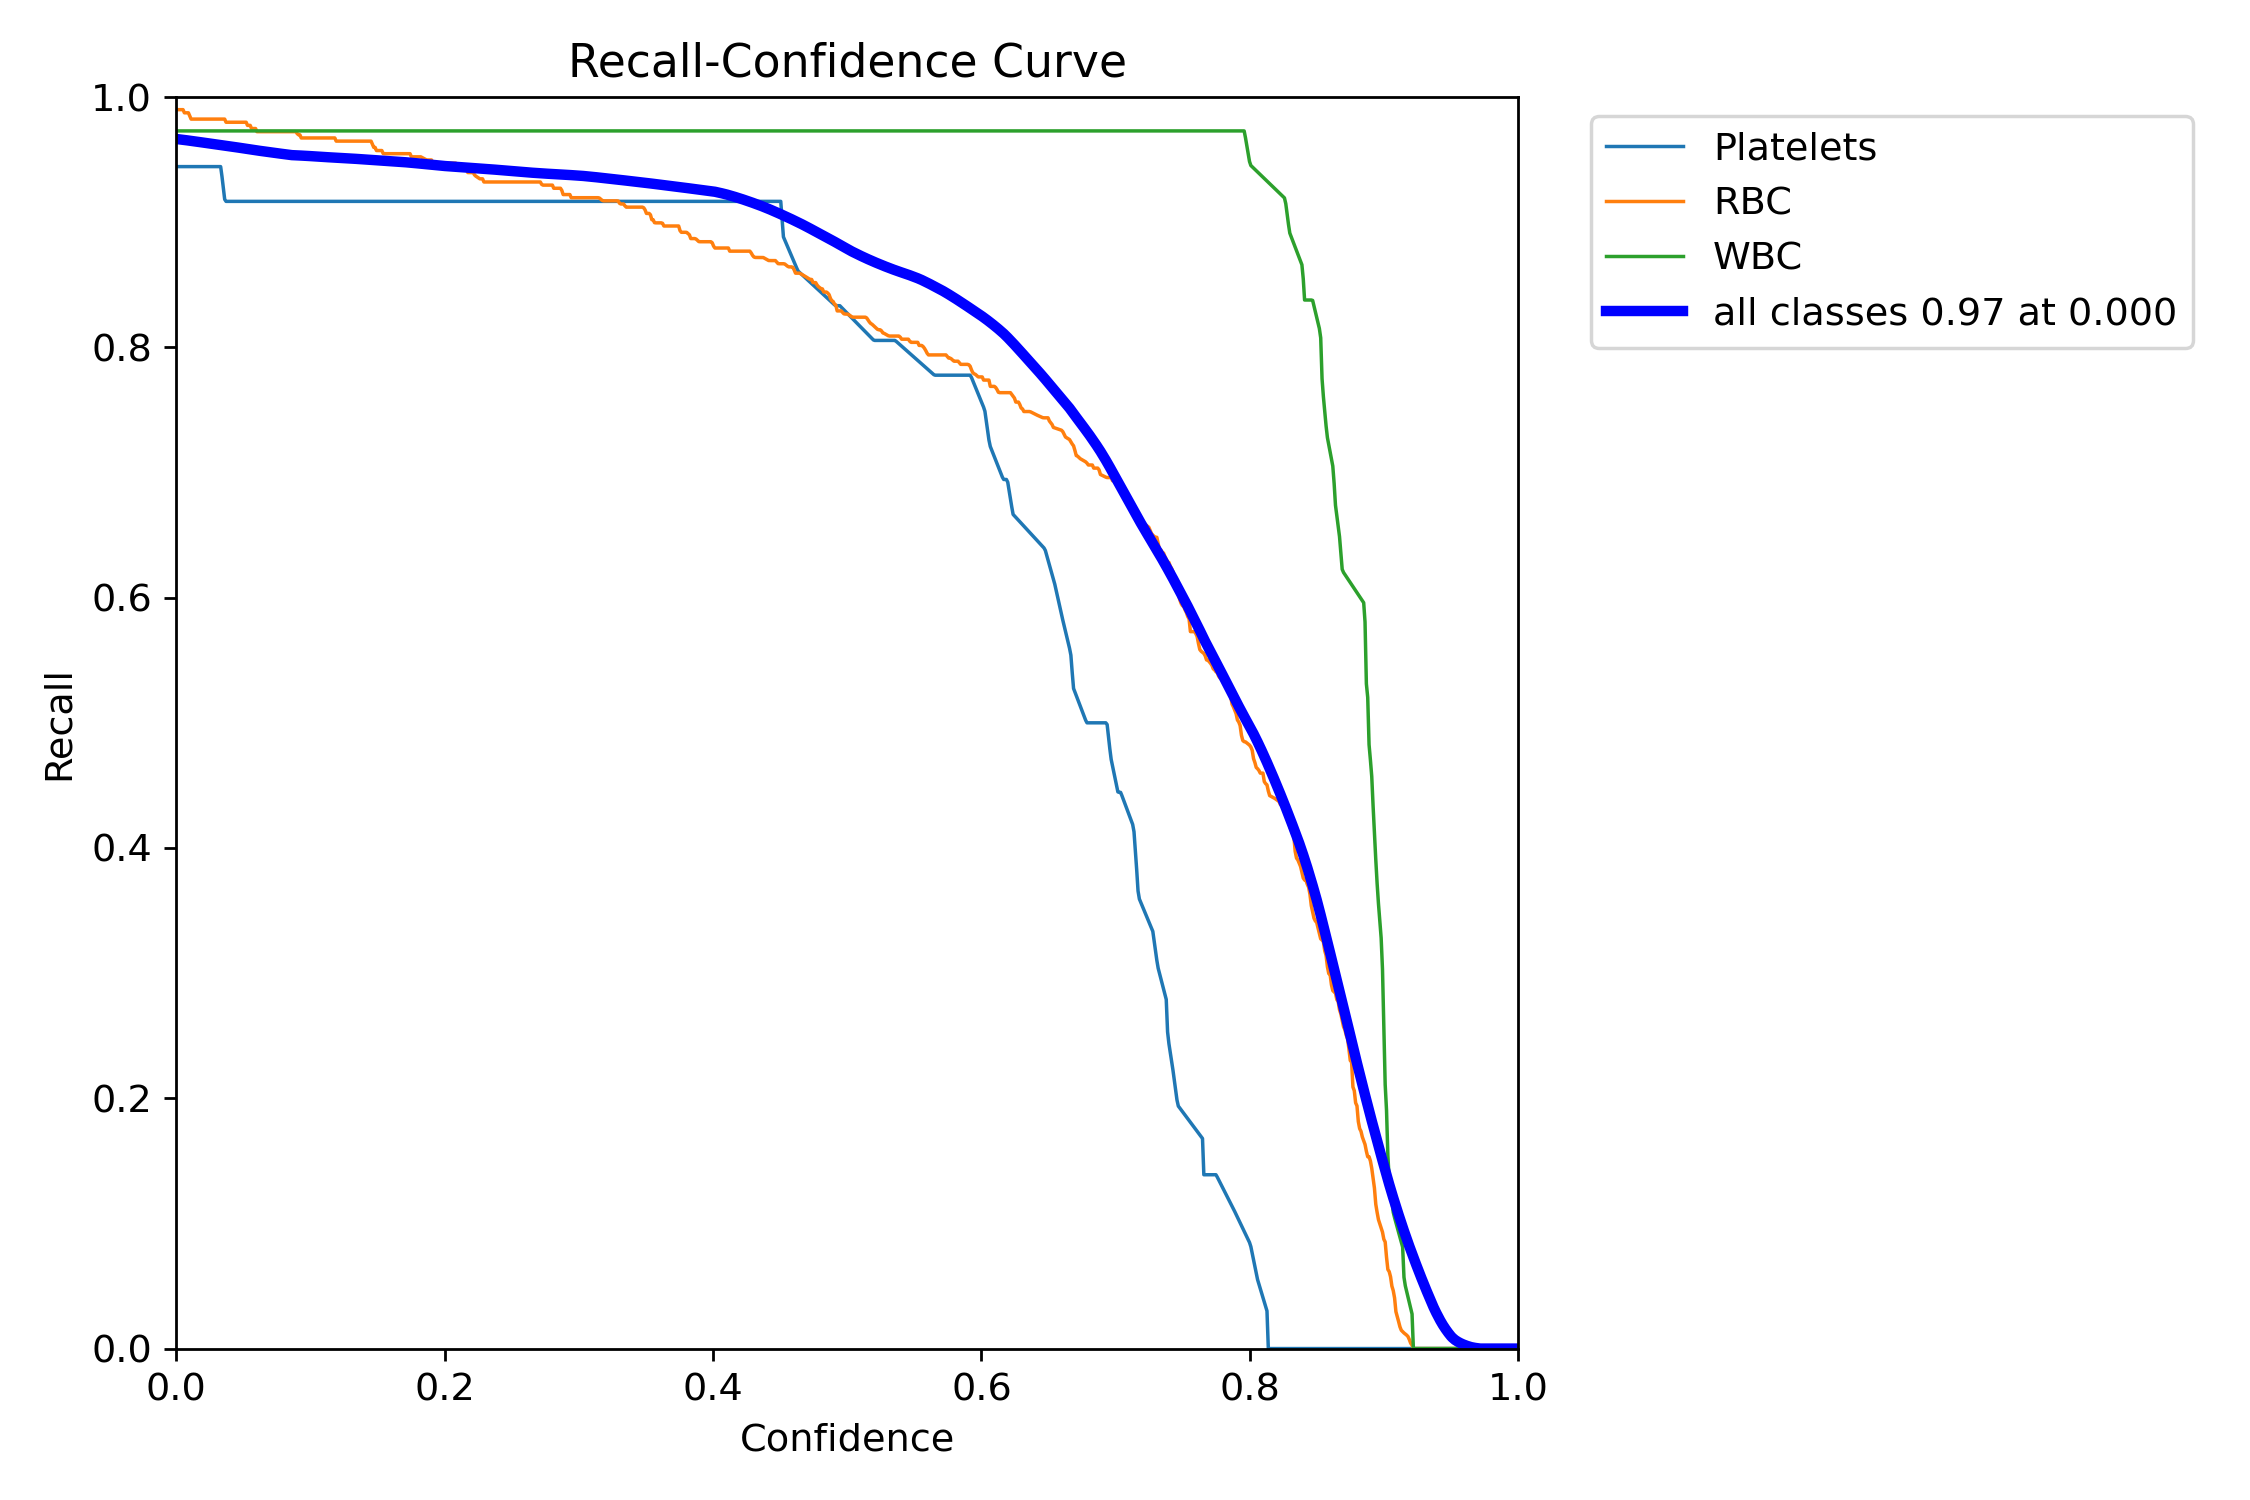

BoxF1_curve.png


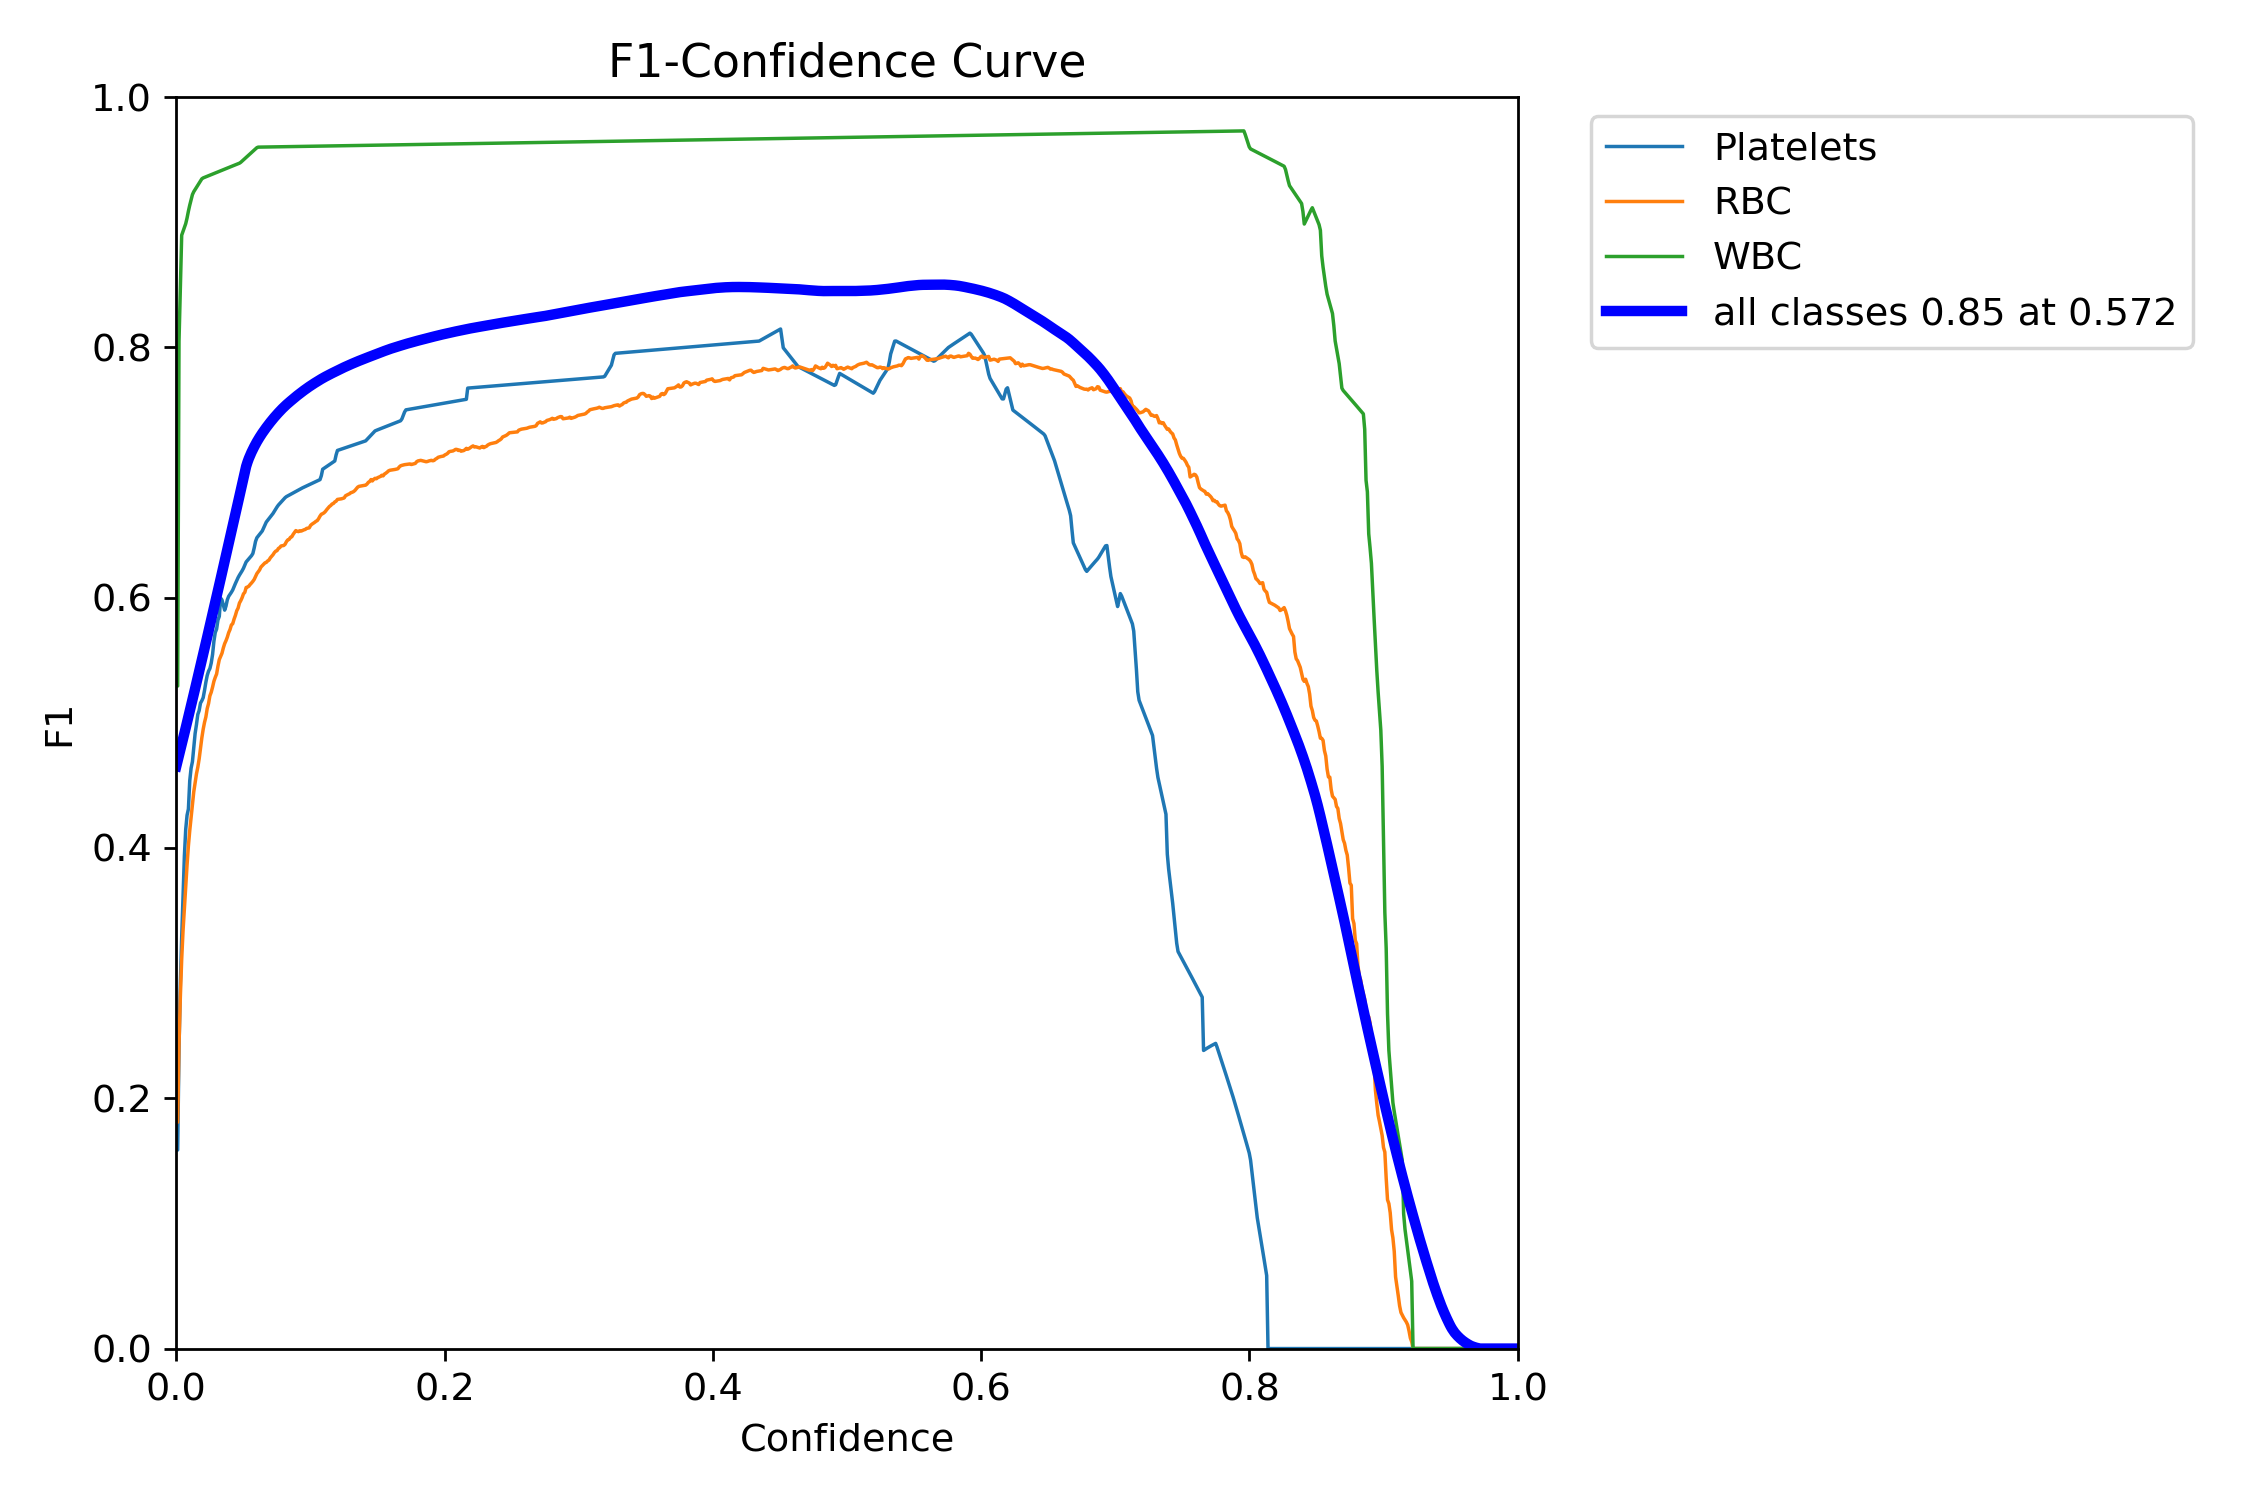

In [132]:
# Display training/evaluation results
for file in [
    "confusion_matrix_normalized.png",
    "confusion_matrix.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]:
    path = os.path.join("results", file)

    print(file)
    display(Image(filename=path, width=900))

In [ ]:
## Confirm saved weights exist
if os.path.exists(WEIGHTS_DIR):
    print("Saved weight files:", os.listdir(WEIGHTS_DIR))
else:
    print(f"Weights folder not found yet: {WEIGHTS_DIR}")

In [129]:
##  Evaluate on the test set
if not os.path.exists(BEST_WEIGHTS):
    raise FileNotFoundError(
        f"best.pt not found at {BEST_WEIGHTS} — did training finish successfully?"
    )

best_model = YOLO(BEST_WEIGHTS)
best_model.model.names = {0: "Platelets", 1: "RBC", 2: "WBC"}
print(best_model.names)

metrics = best_model.val(data=DATA_YAML, split="test")

precision = metrics.box.mp
recall = metrics.box.mr
f1 = 2 * precision * recall / (precision + recall + 1e-9)

print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1           : {f1:.4f}")

for class_id, class_name in metrics.names.items():
    print(f"  {class_name}: AP@0.5 = {metrics.box.ap50[class_id]:.4f}")

{0: 'Platelets', 1: 'RBC', 2: 'WBC'}
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 488.5±146.9 MB/s, size: 12.8 KB)
val: Scanning /content/BCCD-1/test/labels.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 9.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.2s
                   all         36        471      0.857      0.848      0.888      0.605
             Platelets         20         36      0.815      0.778       0.83      0.403
                   RBC         34        398      0.791      0.794      0.862      0.613
                   WBC         35         37      0.965      0.973      0.971        0.8
Speed: 5.6ms preprocess, 4.3ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to /content/ru


image 1/36 /content/BCCD-1/test/images/BloodImage_00038_jpg.rf.36f08e3f12fb6946013ba52984ebd08d.jpg: 416x416 2 Plateletss, 25 RBCs, 1 WBC, 14.0ms
image 2/36 /content/BCCD-1/test/images/BloodImage_00044_jpg.rf.32bbc9746e0d148acc1d36ccf0e16bdf.jpg: 416x416 4 Plateletss, 18 RBCs, 2 WBCs, 9.8ms
image 3/36 /content/BCCD-1/test/images/BloodImage_00062_jpg.rf.47b8b747a3b8799f693ba26504054872.jpg: 416x416 2 Plateletss, 18 RBCs, 1 WBC, 8.7ms
image 4/36 /content/BCCD-1/test/images/BloodImage_00090_jpg.rf.dca5066072f8269ffa70549119562118.jpg: 416x416 3 Plateletss, 16 RBCs, 1 WBC, 8.0ms
image 5/36 /content/BCCD-1/test/images/BloodImage_00099_jpg.rf.927b04d997fcaebbc71fa8764d6e86c3.jpg: 416x416 2 Plateletss, 19 RBCs, 1 WBC, 7.6ms
image 6/36 /content/BCCD-1/test/images/BloodImage_00112_jpg.rf.82dc2f6dbf66ba5abfd75fbb9e8440ec.jpg: 416x416 1 Platelets, 22 RBCs, 1 WBC, 7.7ms
image 7/36 /content/BCCD-1/test/images/BloodImage_00113_jpg.rf.9edb51ad5b4a559986b14a4e41767f76.jpg: 416x416 1 Platelets, 15 RBC

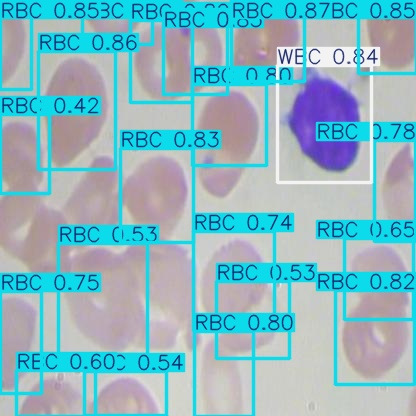

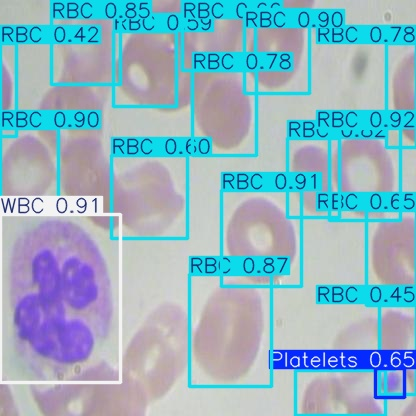

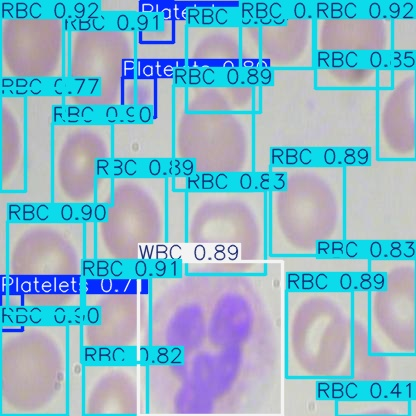

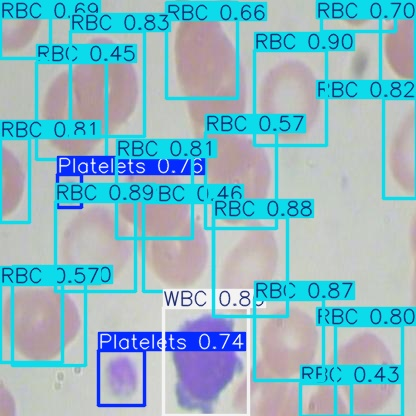

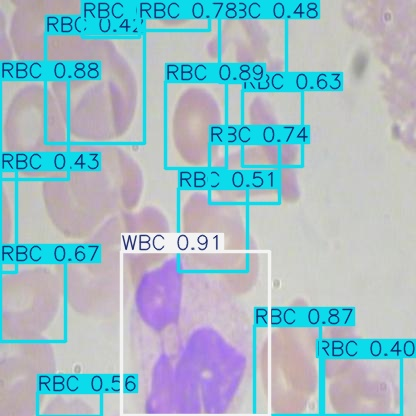

In [133]:
##  Run inference + display
test_images = os.path.join(DATASET_DIR, "test", "images")

results = best_model.predict(
    source=test_images,
    imgsz=CONFIG["img_size"],
    conf=CONFIG["conf_threshold"],
    save=True,
)

detect_dir = results[0].save_dir
result_images = glob.glob(os.path.join(detect_dir, "*.jpg"))[:5]

for image_path in result_images:
    display(Image(filename=image_path))

In [ ]:
## Save trained weights to Drive

drive_destination = "/content/drive/MyDrive/ML_Datasets /best.pt"
if os.path.exists(BEST_WEIGHTS):
    import shutil
    shutil.copy(BEST_WEIGHTS, drive_destination)
    print(f"Copied weights to: {drive_destination}")
else:
    print(f"Nothing to copy — {BEST_WEIGHTS} not found.")

In [ ]:
## Copy weights into local weights/ folder (for Streamlit)
import shutil
os.makedirs("weights", exist_ok=True)
shutil.copy("/content/drive/MyDrive/ML_Datasets /best.pt", "weights/best.pt")
print(os.path.exists("weights/best.pt"))

In [134]:
## Install Streamlit
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.0 MB/s eta 0:00:00


In [135]:
%%writefile src/streamlit_app.py
import streamlit as st
from PIL import Image
from ultralytics import YOLO

st.set_page_config(page_title="Blood Cell Detection (YOLOv8)")
st.title("Blood Cell Detection (YOLOv8)")
st.write("Upload a blood cell microscope image to detect RBC, WBC, and Platelets.")

WEIGHTS_PATH = "weights/best.pt"

@st.cache_resource
def load_model():
    model = YOLO(WEIGHTS_PATH)
    model.model.names = {0: "Platelets", 1: "RBC", 2: "WBC"}
    return model

model = load_model()

uploaded_file = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded image", use_column_width=True)

    result = model.predict(image, conf=0.4)[0]
    st.image(result.plot()[..., ::-1], caption="Detections", use_column_width=True)

    st.subheader("Predictions")
    for box in result.boxes:
        st.write(f"{model.names[int(box.cls)]} — confidence: {float(box.conf):.2f}")

Overwriting src/streamlit_app.py


In [136]:
##  Launch Streamlit
!npm install -g localtunnel
!streamlit run streamlit_app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 6s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠏⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://short-tips-cut.loca.lt
^C


In [ ]:
## requirements.txt
%%writefile requirements.txt
ultralytics
streamlit
pillow

In [ ]:
## .gitignore
%%writefile .gitignore
.env
__pycache__/
*.pyc
drive/
.config/
sample_data/

In [ ]:
## README.md
# Blood Cell Detection with YOLOv8
%%writefile README.md

![Python](https://img.shields.io/badge/Python-3.12-blue)
![YOLOv8](https://img.shields.io/badge/Model-YOLOv8n-orange)
![License](https://img.shields.io/badge/License-MIT-green)

![Sample detection](results/sample_predictions.png)

## Contents
- [Overview](#overview)
- [Dataset](#dataset)
- [Methodology](#methodology)
- [Results](#results)
- [Key Learnings](#key-learnings)
- [Project Structure](#project-structure)
- [Running the Project](#running-the-project)
- [Future Improvements](#future-improvements)
- [Credits](#credits)

## Overview
This project detects and classifies blood cells in microscope images using a custom-trained YOLOv8 model and provides an interactive Streamlit interface for visualizing predictions.
* Red Blood Cells (RBC)
* White Blood Cells (WBC)
* Platelets

The goal is to explore how modern computer vision techniques can support automated and low-cost blood analysis.

---

## Dataset
**[BCCD (Blood Cell Count Dataset)](https://public.roboflow.com/object-detection/bccd)**
* 874 annotated microscope images
* 3 object classes (RBC, WBC, Platelets)
* Exported and managed using [Roboflow](https://roboflow.com)

---

## Technologies Used

- Python
- PyTorch
- Ultralytics YOLOv8
- OpenCV
- Roboflow
- Streamlit
- Google Colab

---


## Methodology

### Model
* YOLOv8n (Nano)
* Initialized from COCO-pretrained weights

### Why Transfer Learning?
Training an object detector from scratch requires large amounts of labeled data and computational resources. By starting from COCO-pretrained weights, the model already understands generic visual patterns such as edges, shapes, and textures.

Fine-tuning on the BCCD dataset allows the detector to adapt these learned features to medical images while requiring significantly less data and training time.

### Training Configuration
| Parameter  | Value                            |
| ---------- | --------------------------------- |
| Model      | YOLOv8n                          |
| Epochs     | 100                               |
| Image Size | 416 * 416                         |
| Batch Size | 16                                 |
| Optimizer  | Default YOLOv8 Training Pipeline  |

---

## Results

### Training Curves
![Training results](results/results.png)

### Test Set Performance
| Metric       | Score |
| ------------ | ----- |
| mAP@0.5      | 0.888 |
| mAP@0.5:0.95 | 0.605 |
| Precision    | 0.857 |
| Recall       | 0.848 |
| F1 Score     | 0.853 |

### Confusion Matrix & Precision-Recall Curve
![Confusion matrix](results/confusion_matrix_normalized.png)
![PR curve](results/BoxPR_curve.png)

### Per-Class AP@0.5
| Class     | AP@0.5 |
| --------- | ------ |
| Platelets | 0.83   |
| RBC       | 0.86   |
| WBC       | 0.97   |

White Blood Cells achieved the highest detection performance because their large size and distinctive nucleus make them visually easier to identify. Red Blood Cells were the most challenging due to frequent overlap and dense clustering.

---

## Key Learnings
* Class imbalance becomes more apparent when examining per-class metrics rather than only overall performance.
* mAP@0.5:0.95 provides a more rigorous evaluation than mAP@0.5 because it rewards accurate localization across multiple IoU thresholds.
* Dataset exports should always be verified before training. During this project, class labels were exported as placeholder indices instead of human-readable names, requiring manual validation of the `data.yaml` configuration.

---

## Project Structure
```text
blood-cell-detection-yolov8/
│
├── README.md
├── requirements.txt
│
├── notebooks/
│   └── yolov8_bccd_training.ipynb
│
├── src/
│   └── streamlit_app.py
│
├── weights/
│   └── best.pt
│
└── results/
    ├── sample_predictions.png
    ├── confusion_matrix_normalized.png
    ├── BoxPR_curve.png
    └── results.png
```

---

## Running the Project
Install dependencies:
```bash
pip install -r requirements.txt
```

Launch the Streamlit application:
```bash
streamlit run src/streamlit_app.py
```

Upload a microscope image to visualize blood cell detections produced by the trained YOLOv8 model.

---

## Future Improvements
* Train larger YOLOv8 variants (YOLOv8s / YOLOv8m)
* Apply advanced augmentation techniques
* Address class imbalance using weighted sampling
* Evaluate on additional hematology datasets
* Deploy as a web-based diagnostic support tool

---

## Credits
Built on [Ultralytics YOLOv8](https://github.com/ultralytics/ultralytics). Dataset via [Roboflow](https://roboflow.com).

## License
This project is licensed under the MIT License.